# Неделя 4. Понедельник

## Обучение без учителя


### Кластеризация

### Задание 1

Импортируйте несколько моделей кластеризации: 
* KMeans
* DBSCAN
* https://scikit-learn.org/stable/modules/clustering.html

In [355]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    RobustScaler,
    MinMaxScaler,
    OrdinalEncoder,
    TargetEncoder,
    FunctionTransformer,
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from umap import UMAP
import umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import sklearn

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

sklearn.set_config(transform_output="pandas")
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    homogeneity_score,
    completeness_score,
    silhouette_score,
    rand_score,
)
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

Импортируй датасет: `path = 'aux/X_train.txt'`

* В этом файле содержатся датчики мобильного телефона для различных активностей пользователя. Необходимо выявить какие кластеры можно выделить в данных и предположить, каким состояниями они соответствуют (пользователь в покое, идет, сидит и тд.)

* Фичей много, и здесь не особо нужно, что каждая из них значит, однако более детально об эксперименте можно прочитать [тут](https://data.world/uci/human-activity-recognition)

In [54]:
path = "data/X_train.txt"
X_train = pd.read_csv(path, sep="\s+", header=None)

1. Примени ряд кластеризационных [моделей](https://scikit-learn.org/stable/modules/clustering.html) на импортированном датасете.

In [55]:
dbs = DBSCAN(eps=2)
km = KMeans(n_clusters=3, n_init=25, random_state=42, max_iter=500)
agg = AgglomerativeClustering(3)

In [56]:
# km.fit(X_train)

In [57]:
dbs.fit(X_train)

,eps,2
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [74]:
agg.fit(X_train)

,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


2. Определи и зафиксируй количество кластеров, которое наиболее оптимально с точки зрения метрики `silhouette`. Установи библиотеку [`yellowbrick`](https://www.scikit-yb.org/en/latest/api/cluster/silhouette.html) и визуализируй результаты для использованных методов (при использовании метода K-means). 

In [59]:
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

##### KMeans

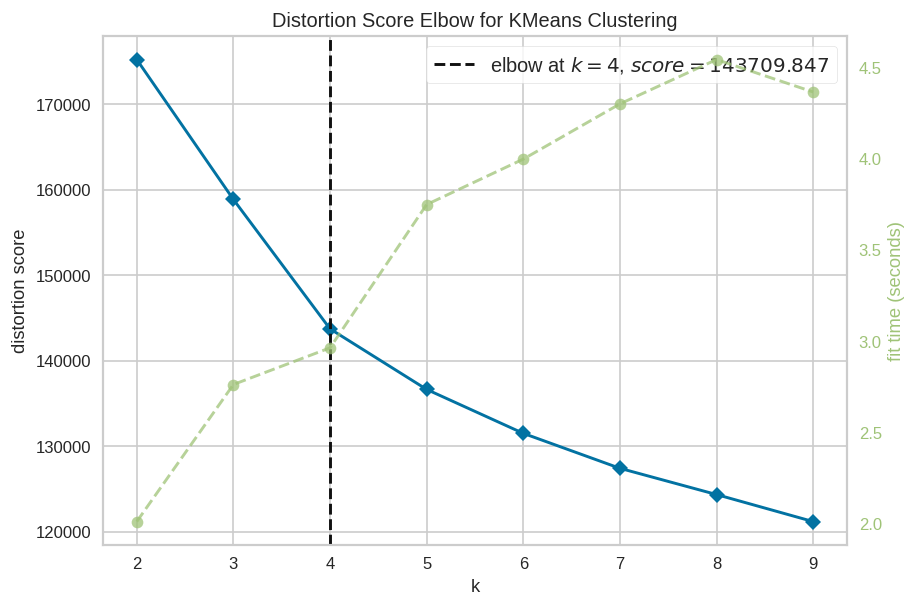

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [101]:
visualizer = KElbowVisualizer(km, k=(2, 10))
visualizer.fit(X_train)
visualizer.show()

In [102]:
km = KMeans(n_clusters=3, n_init=25, random_state=42, max_iter=500)
km.fit(X_train)

,n_clusters,3
,init,'k-means++'
,n_init,25
,max_iter,500
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


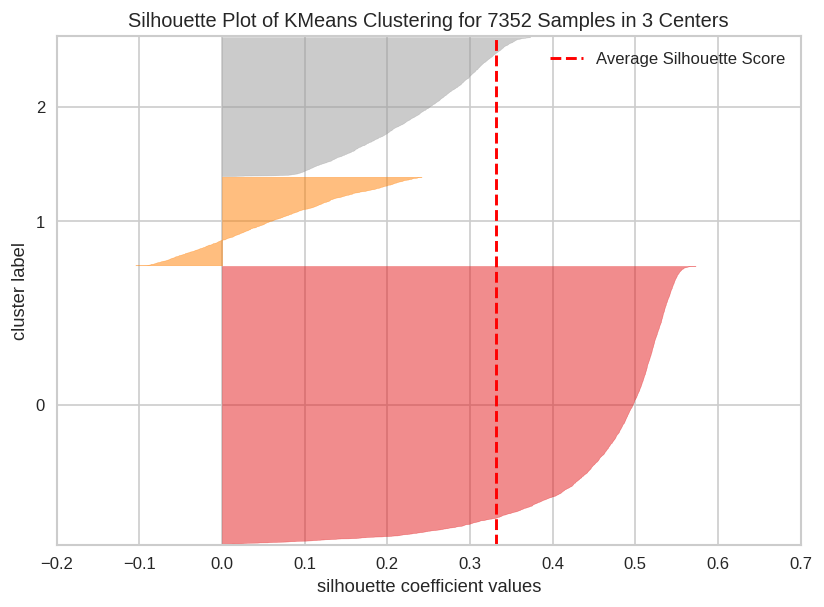

''

In [103]:
visualizer_km = SilhouetteVisualizer(km)
visualizer_km.fit(X_train)
visualizer_km.show()
;

# ❓

Почему метрика `silhouette` может быть бессмысленной в некоторых случаях? Приведи пример такой ситуации. 

> ответ тут

4. Примените [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), [UMAP](https://umap-learn.readthedocs.io/en/latest/) и [tSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) декомпозиции и визуализируйте полученные объекты в новом (двумерном или трехмерном) пространстве. В процессе перебирайте возможные параметры и сравнивайте результат по визуализациям.

In [63]:
pca = PCA(n_components=2)
tsne = TSNE(n_components=2, perplexity=30)
ump = umap.UMAP(n_components=2, n_neighbors=100)

In [64]:
X_pca = pca.fit_transform(X_train)
X_tsne = tsne.fit_transform(X_train)
X_umap = ump.fit_transform(X_train)

Text(0.5, 1.0, 'UMAP')

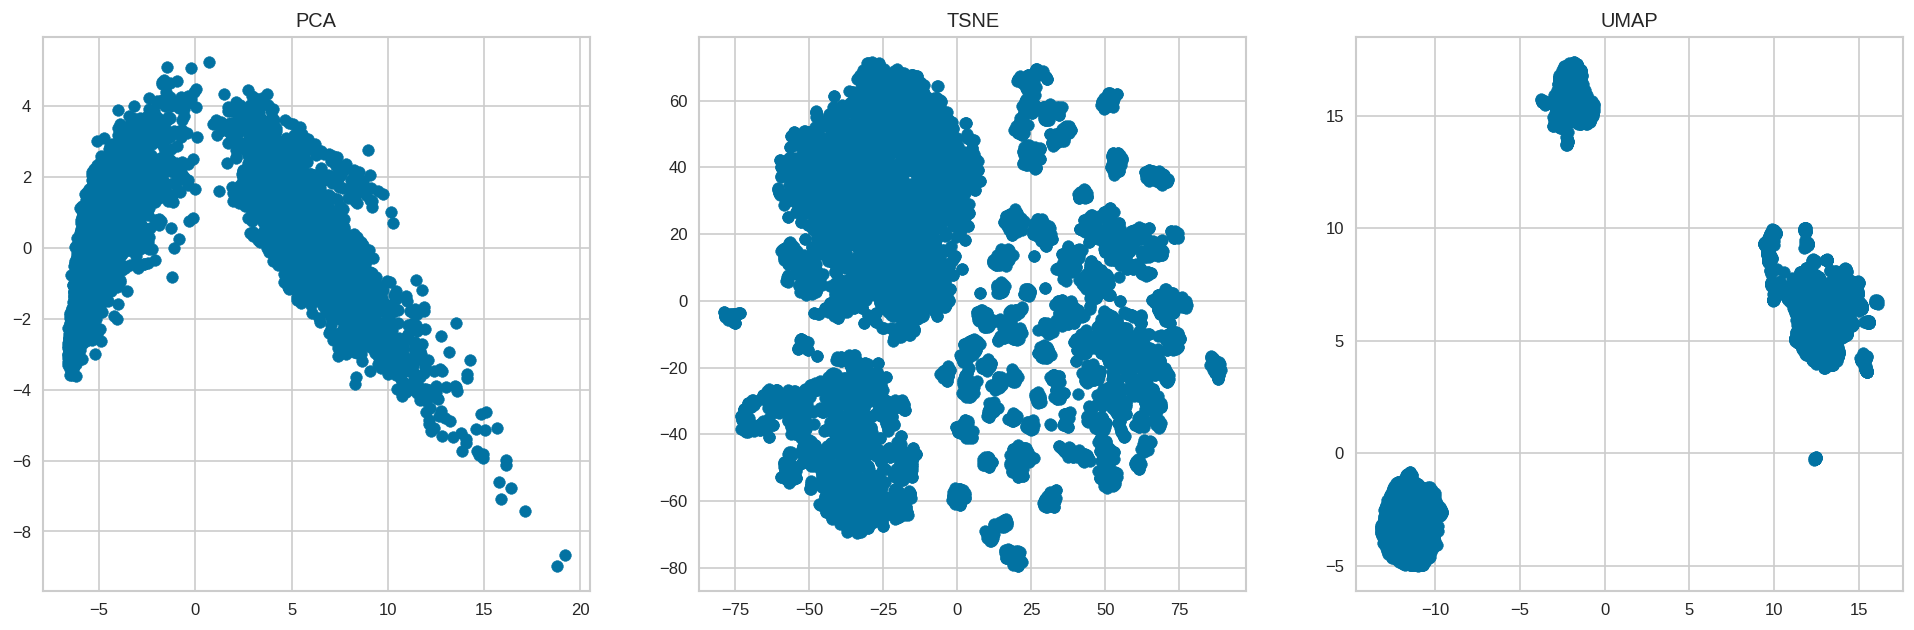

In [65]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.scatter(X_pca.iloc[:, 0], X_pca.iloc[:, 1])
ax2.scatter(X_tsne.iloc[:, 0], X_tsne.iloc[:, 1])
ax3.scatter(X_umap[:, 0], X_umap[:, 1])

ax1.set_title("PCA")
ax2.set_title("TSNE")
ax3.set_title("UMAP")

5. Повтори шаги 1 и 2 для трансформированных данных. 

In [66]:
# dbs1 = DBSCAN(eps=1)
# km1 = KMeans(n_clusters=4, n_init=25, random_state=42, max_iter=500)
# agg1 = AgglomerativeClustering()

In [ ]:
X = {"pca": X_pca, "tsne": X_tsne, "umap": X_umap}

models = {
    "KMeans": KMeans(n_clusters=3, n_init=25, random_state=42, max_iter=500),
    "AggCls": AgglomerativeClustering(3),
    "DBSCAN": DBSCAN(eps=1.5),
}

In [105]:
def plot_results(X: dict, models: dict):
    fig, ax = plt.subplots(3, 3, figsize=(12, 12))
    for i in np.arange(3):
        for j in np.arange(3):
            X_ = list(X.values())[i]
            model = list(models.values())[j].fit(X_)
            colors = model.labels_
            sil_score = silhouette_score(X_, model.labels_)
            #
            ax[i, j].scatter(
                np.array(X_)[:, 0],
                np.array(X_)[:, 1],
                c=colors,
                marker=".",
                s=10,
                cmap="rainbow",
            )
            ax[i, j].set_title(
                f"{list(X.keys())[i]}/{list(models.keys())[j]}: sil_score={sil_score:.3f}"
            )

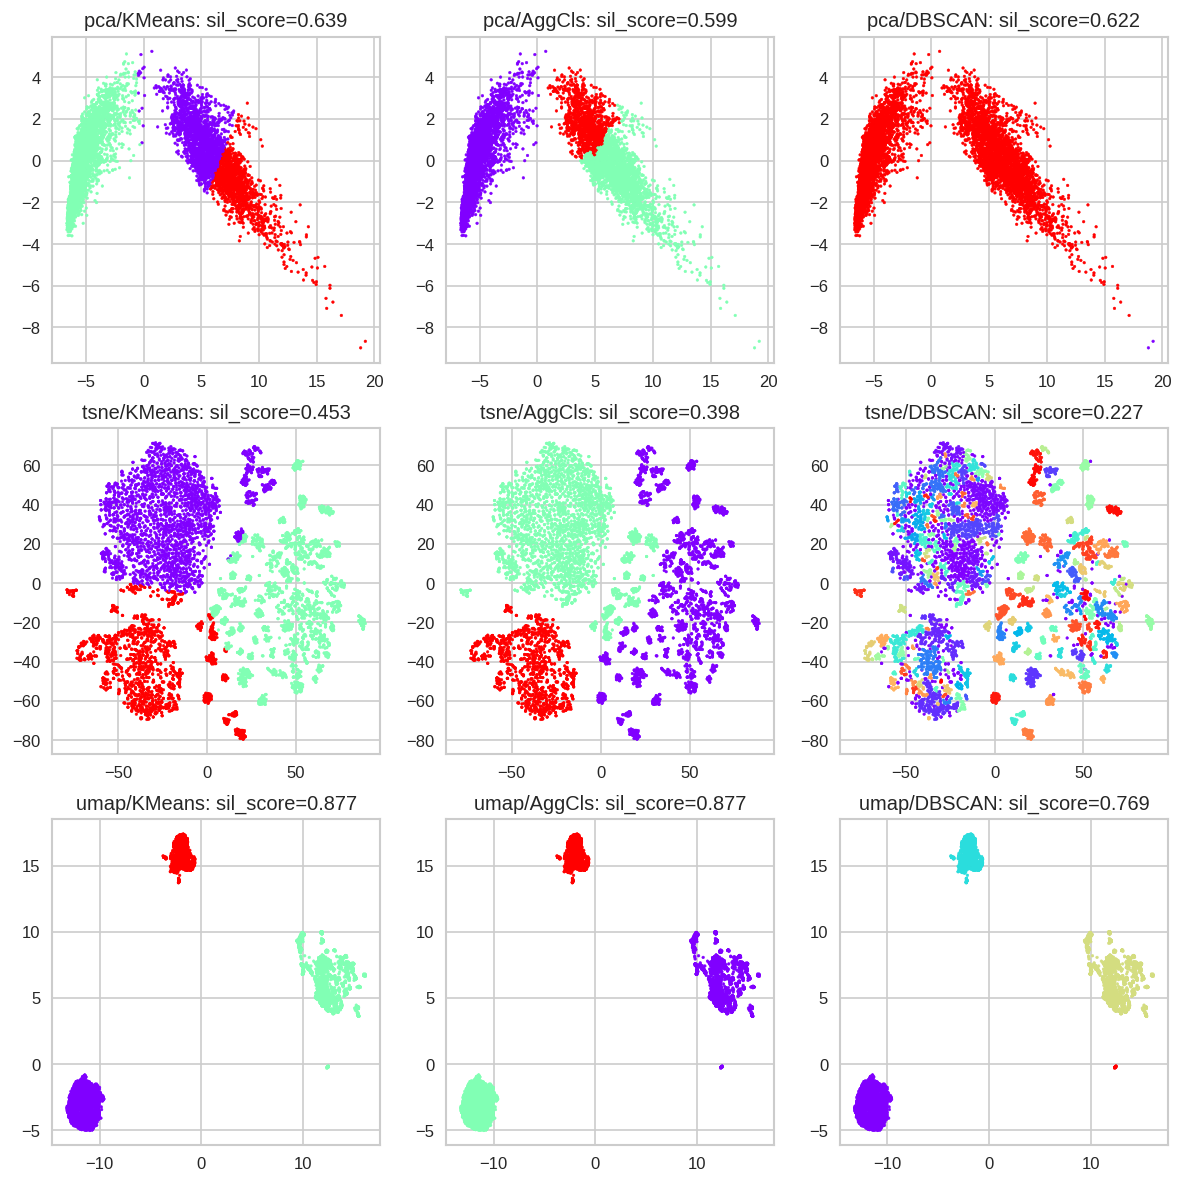

In [106]:
plot_results(X, models)

6. Сделай вывод: какой метод кластеризации и какие преобразования данных дают наилучший результат в контексте метрики силует. 

> Лучшую метрику силуэт дает комбинация UMAP + KMeans/AggCls

7. Визуализируй наиболее успешный результат, цветос выдели кластеры

In [70]:
# code

8. Теперь настало время внешних метрик.

* Подгрузи файл `y_train.txt`. В нем разметка реальных активностей человека, [здесь](https://data.world/uci/human-activity-recognition) можно найти какой класс - какая активность.
* Посчитай внешние метрики $homogenity$ и $completeness$.
* Выбери оптимальное количество кластеров в контексте внешних метрик

In [71]:
path2 = "data/y_train.txt"

In [ ]:
y_train = pd.read_csv(path2, sep="\s+", header=None)

,0
0,5
1,5
2,5
3,5
4,5
...,...
7347,2
7348,2
7349,2
7350,2


In [130]:
dbs1 = DBSCAN(eps=6)
km1 = KMeans(n_clusters=3, n_init=25, random_state=42, max_iter=500)
agg1 = AgglomerativeClustering(3)

In [131]:
dbs1.fit(X_umap)
km1.fit(X_umap)
agg1.fit(X_umap)

,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [132]:
pd.Series(dbs1.labels_).nunique()

3

In [133]:
metrics_umap = pd.DataFrame(
    data={
        "homogenity": [
            homogeneity_score(np.array(y_train.iloc[:, 0]), np.array(km1.labels_)),
            homogeneity_score(np.array(y_train.iloc[:, 0]), np.array(agg1.labels_)),
            homogeneity_score(np.array(y_train.iloc[:, 0]), np.array(dbs1.labels_)),
        ],
        "completeness": [
            completeness_score(np.array(y_train.iloc[:, 0]), np.array(km1.labels_)),
            completeness_score(np.array(y_train.iloc[:, 0]), np.array(agg1.labels_)),
            completeness_score(np.array(y_train.iloc[:, 0]), np.array(dbs1.labels_)),
        ],
        "n_classes": [5, 5, 5],
        "n_clusters": [
            pd.Series(km1.labels_).nunique(),
            pd.Series(agg1.labels_).nunique(),
            pd.Series(dbs1.labels_).nunique(),
        ],
    },
    index=["KMeans", "AggCls", "DBSCAN"],
)
metrics_umap

,homogenity,completeness,n_classes,n_clusters
KMeans,0.579258,0.989639,5,3
AggCls,0.579258,0.989639,5,3
DBSCAN,0.579258,0.989639,5,3


In [134]:
dbs1.fit(X_pca)
km1.fit(X_pca)
agg1.fit(X_pca)

,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [135]:
metrics_pca = pd.DataFrame(
    data={
        "homogenity": [
            homogeneity_score(np.array(y_train.iloc[:, 0]), np.array(km1.labels_)),
            homogeneity_score(np.array(y_train.iloc[:, 0]), np.array(agg1.labels_)),
            homogeneity_score(np.array(y_train.iloc[:, 0]), np.array(dbs1.labels_)),
        ],
        "completeness": [
            completeness_score(np.array(y_train.iloc[:, 0]), np.array(km1.labels_)),
            completeness_score(np.array(y_train.iloc[:, 0]), np.array(agg1.labels_)),
            completeness_score(np.array(y_train.iloc[:, 0]), np.array(dbs1.labels_)),
        ],
        "n_classes": [5, 5, 5],
        "n_clusters": [
            pd.Series(km1.labels_).nunique(),
            pd.Series(agg1.labels_).nunique(),
            pd.Series(dbs1.labels_).nunique(),
        ],
    },
    index=["KMeans", "AggCls", "DBSCAN"],
)
metrics_pca

,homogenity,completeness,n_classes,n_clusters
KMeans,0.405225,0.728108,5,3
AggCls,0.413203,0.753553,5,3
DBSCAN,0.000000,1.000000,5,1


In [136]:
dbs1.fit(X_tsne)
km1.fit(X_tsne)
agg1.fit(X_tsne)

,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [137]:
metrics_tsne = pd.DataFrame(
    data={
        "homogenity": [
            homogeneity_score(np.array(y_train.iloc[:, 0]), np.array(km1.labels_)),
            homogeneity_score(np.array(y_train.iloc[:, 0]), np.array(agg1.labels_)),
            homogeneity_score(np.array(y_train.iloc[:, 0]), np.array(dbs1.labels_)),
        ],
        "completeness": [
            completeness_score(np.array(y_train.iloc[:, 0]), np.array(km1.labels_)),
            completeness_score(np.array(y_train.iloc[:, 0]), np.array(agg1.labels_)),
            completeness_score(np.array(y_train.iloc[:, 0]), np.array(dbs1.labels_)),
        ],
        "n_classes": [5, 5, 5],
        "n_clusters": [
            pd.Series(km1.labels_).nunique(),
            pd.Series(agg1.labels_).nunique(),
            pd.Series(dbs1.labels_).nunique(),
        ],
    },
    index=["KMeans", "AggCls", "DBSCAN"],
)
metrics_tsne

,homogenity,completeness,n_classes,n_clusters
KMeans,0.457307,0.753225,5,3
AggCls,0.486896,0.833580,5,3
DBSCAN,0.647945,0.747543,5,14


<img src="https://icons.iconarchive.com/icons/icons8/windows-8/256/Programming-Github-icon.png" width=32 /> Пора закоммить изменения в файле. Сделай это с сообщением: 
`"Clustering: task 1 finished"`

После коммита выполни `!git status` в ячейке ниже. 

In [ ]:
# code

### Задание 2

Скачай с kaggle [датасет](https://www.kaggle.com/arjunbhasin2013/ccdata) с информацией об обладателях кредитных карт. Кластеризируй объекты и проанализируй результат. 

In [315]:
df = pd.read_csv("data/CC GENERAL.csv")
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [316]:
df.nunique()

CUST_ID                             8950
BALANCE                             8871
BALANCE_FREQUENCY                     43
PURCHASES                           6203
ONEOFF_PURCHASES                    4014
INSTALLMENTS_PURCHASES              4452
CASH_ADVANCE                        4323
PURCHASES_FREQUENCY                   47
ONEOFF_PURCHASES_FREQUENCY            47
PURCHASES_INSTALLMENTS_FREQUENCY      47
CASH_ADVANCE_FREQUENCY                54
CASH_ADVANCE_TRX                      65
PURCHASES_TRX                        173
CREDIT_LIMIT                         205
PAYMENTS                            8711
MINIMUM_PAYMENTS                    8636
PRC_FULL_PAYMENT                      47
TENURE                                 7
dtype: int64

In [317]:
df_clear = df.copy().drop("CUST_ID", axis=1)

In [318]:
df_clear.isna().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [331]:
df_clear = df_clear.dropna()
df_clear

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8943,5.871712,0.500000,20.90,20.90,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,1,500.0,58.644883,43.473717,0.000000,6
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [340]:
df_clear.isna().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

''

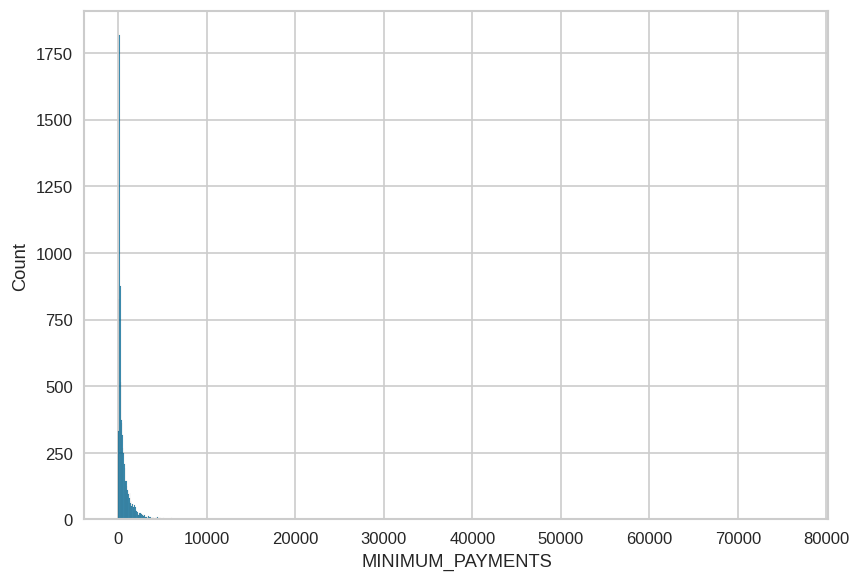

In [341]:
sns.histplot(df_clear["MINIMUM_PAYMENTS"])
;

<Axes: xlabel='CREDIT_LIMIT', ylabel='Count'>

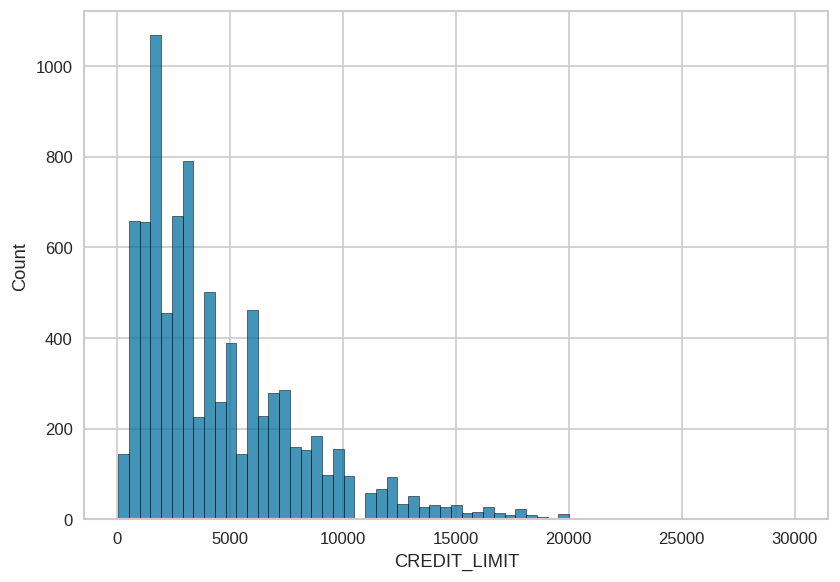

In [334]:
sns.histplot(df_clear["CREDIT_LIMIT"])

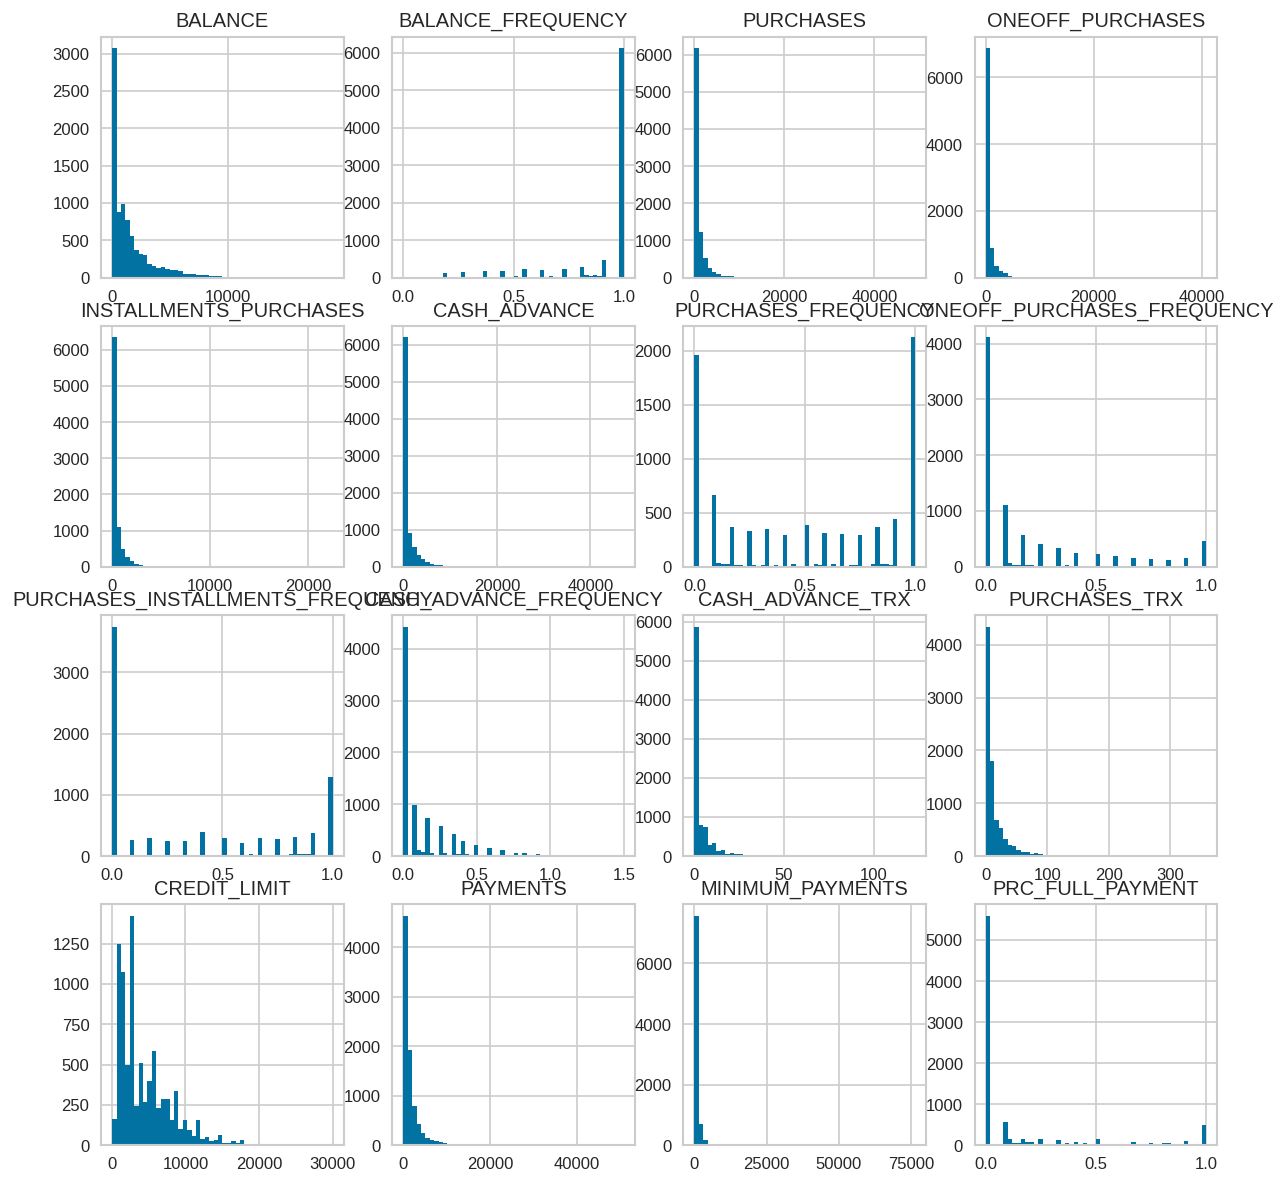

In [335]:
fig, ax = plt.subplots(4, 4, figsize=(12, 12))
column_names = df_clear.columns.to_list()
k = 0
for i in np.arange(4):
    for j in np.arange(4):
        ax[i, j].hist(df_clear[column_names[k]], bins=50)
        ax[i, j].set_title(column_names[k])
        k += 1

In [342]:
numeric_cols = df_clear.select_dtypes(include=["float", int]).columns
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clear[numeric_cols])

In [343]:
df_scaled.isna().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

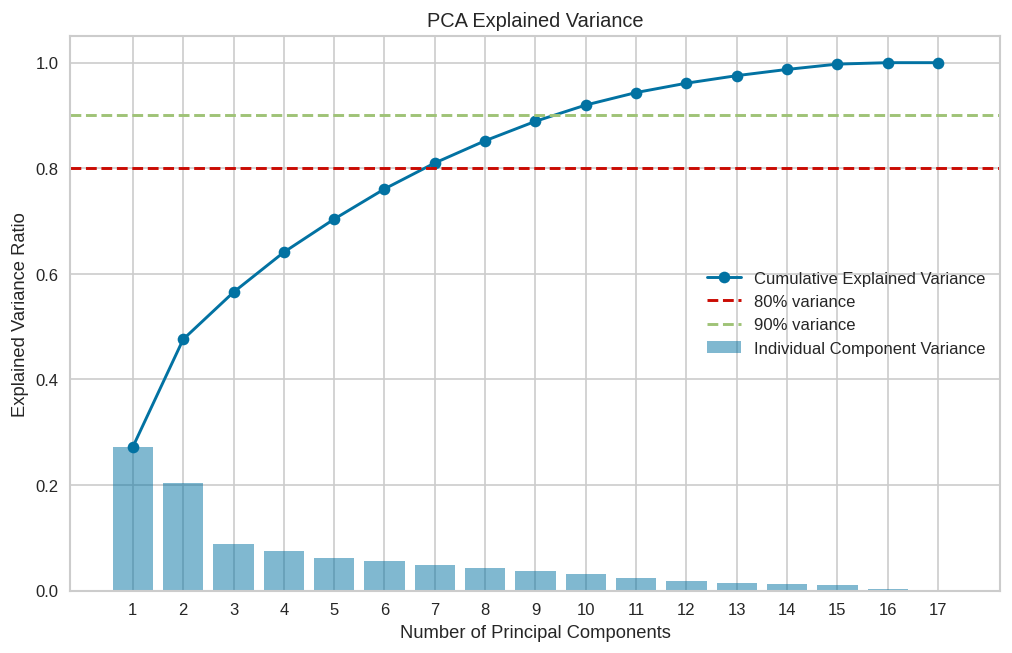

In [344]:
pca_full = PCA(n_components=len(numeric_cols))
df_pca_all = pca_full.fit_transform(df_scaled)

explained_variance = pca_full.explained_variance_ratio_

cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(numeric_cols) + 1),
    cumulative_variance,
    marker="o",
    label="Cumulative Explained Variance",
)
plt.bar(
    range(1, len(numeric_cols) + 1),
    explained_variance,
    alpha=0.5,
    label="Individual Component Variance",
)
plt.axhline(y=0.8, color="r", linestyle="--", label="80% variance")
plt.axhline(y=0.9, color="g", linestyle="--", label="90% variance")
plt.xticks(range(1, len(numeric_cols) + 1))
plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

In [326]:
# for_scaling = df_clear.drop(
#     [
#         "TENURE",
#         "BALANCE_FREQUENCY",
#         "PURCHASES_FREQUENCY",
#         "ONEOFF_PURCHASES_FREQUENCY",
#         "PURCHASES_INSTALLMENTS_FREQUENCY",
#         "CASH_ADVANCE_FREQUENCY",
#     ],
#     axis=1,
# ).columns.to_list()
# imputer = ColumnTransformer(
#     [
#         (
#             "median imputer",
#             SimpleImputer(strategy="median"),
#             ["CREDIT_LIMIT", "MINIMUM_PAYMENTS"],
#         ),
#         # (
#         #     "min imputer",
#         #     SimpleImputer(strategy="constant", fill_value=0),
#         #     ["MINIMUM_PAYMENTS"],
#         # ),
#     ],
#     verbose_feature_names_out=False,
#     remainder="passthrough",
# )
# scaler = ColumnTransformer(
#     [("scaler", RobustScaler(), for_scaling)],
#     verbose_feature_names_out=False,
#     remainder="passthrough",
# )
# processing = Pipeline([("imputer", imputer), ("scaler", scaler)])
# for_scaling

In [325]:
# df_imputed = imputer.fit_transform(df_clear)
# df_log = df_imputed.copy()
# for c in for_scaling:
#     df_log[c] = np.log(df_log[c])
# df_processed = scaler.fit_transform(df_log)

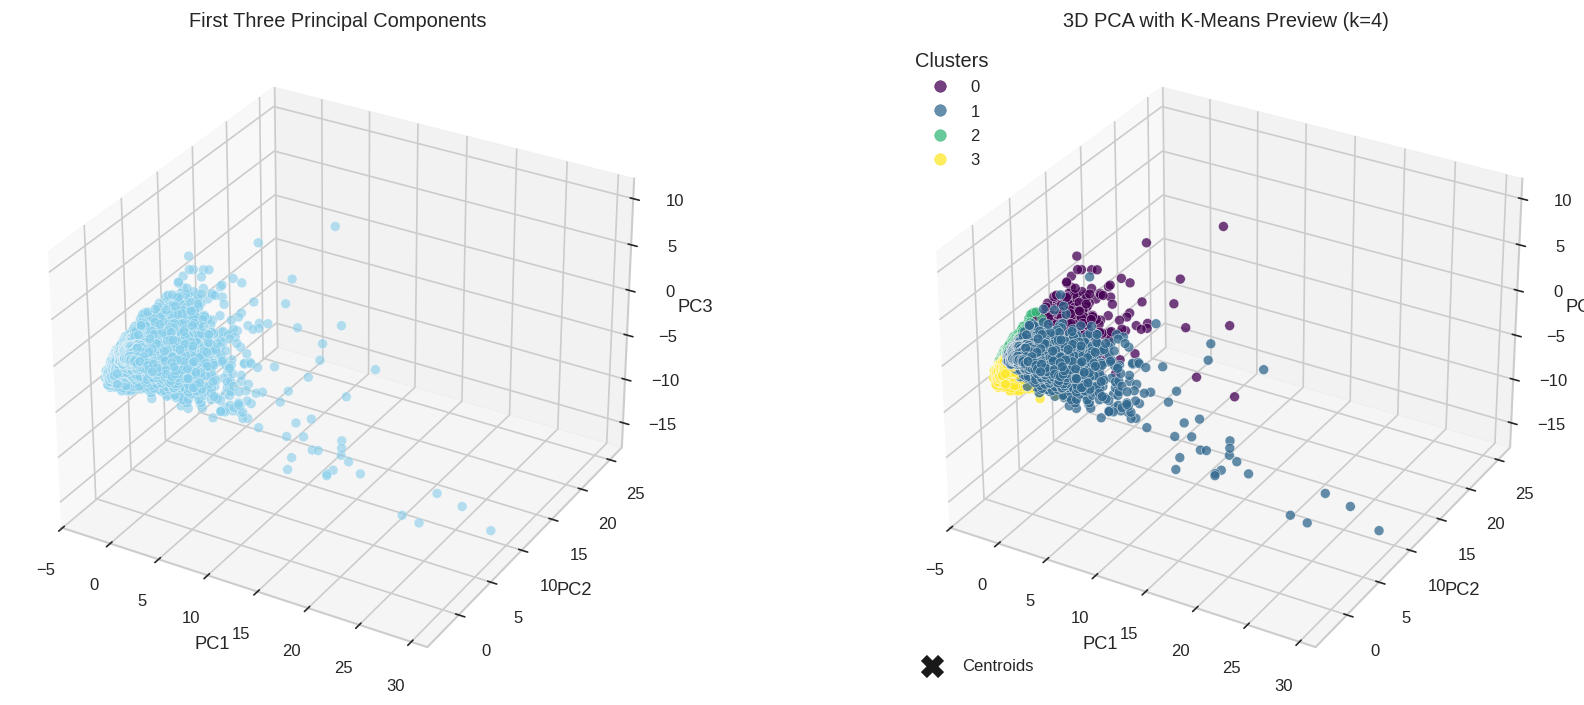

In [350]:
df_pca = df_pca_all.iloc[:, :9]
df_pca_3 = df_pca.iloc[:, :3]
kmeans_preview = KMeans(n_clusters=4, random_state=42)
labels_preview = kmeans_preview.fit_predict(df_pca)
centers_3d = kmeans_preview.cluster_centers_[:, :3]

sil = silhouette_score(df_pca, labels_preview)

fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(
    df_pca_3.iloc[:, 0],
    df_pca_3.iloc[:, 1],
    df_pca_3.iloc[:, 2],
    c="skyblue",
    s=35,
    alpha=0.6,
    edgecolors="w",
)
ax1.set_title("First Three Principal Components")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_zlabel("PC3")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
sc = ax2.scatter(
    df_pca_3.iloc[:, 0],
    df_pca_3.iloc[:, 1],
    df_pca_3.iloc[:, 2],
    c=labels_preview,
    cmap="viridis",
    s=35,
    alpha=0.75,
    edgecolors="w",
)
ax2.scatter(
    centers_3d[:, 0],
    centers_3d[:, 1],
    centers_3d[:, 2],
    marker="X",
    s=180,
    c="black",
    alpha=0.9,
    label="Centroids",
)
ax2.set_title("3D PCA with K-Means Preview (k=4)")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")
legend1 = ax2.legend(*sc.legend_elements(), title="Clusters", loc="upper left")
ax2.add_artist(legend1)
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

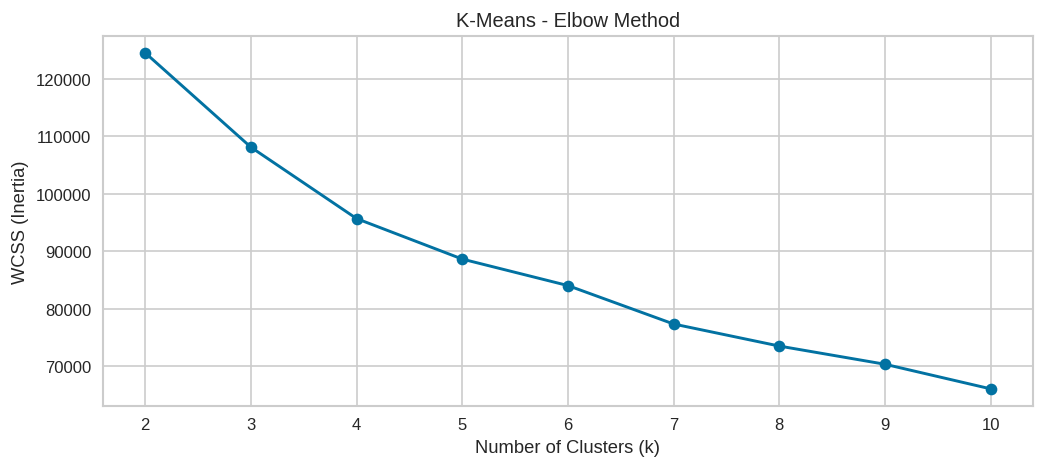

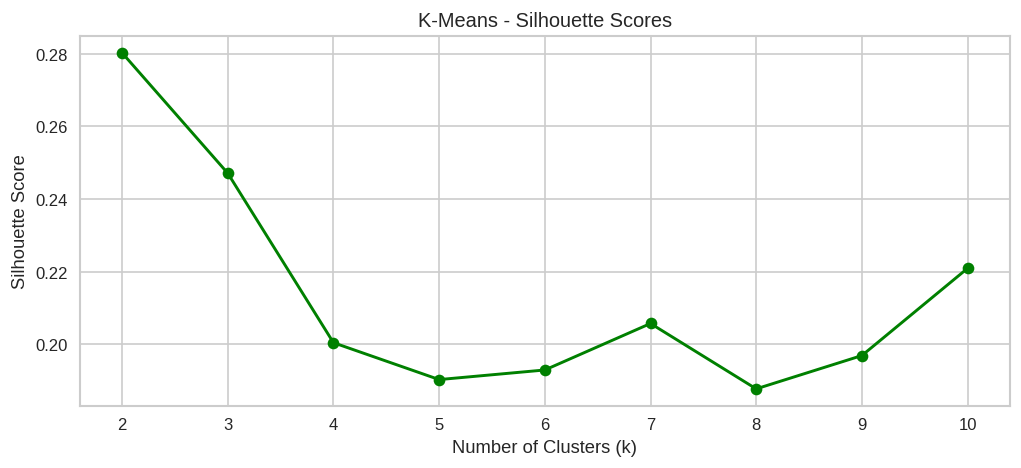

In [351]:
# K-Means with Elbow Method and Silhouette
wcss = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(df_scaled, labels))

# Elbow plot
plt.figure(figsize=(10, 4))
plt.plot(K_range, wcss, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("K-Means - Elbow Method")
plt.show()

# Silhouette score plot
plt.figure(figsize=(10, 4))
plt.plot(K_range, sil_scores, marker="o", color="green")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means - Silhouette Scores")
plt.show()

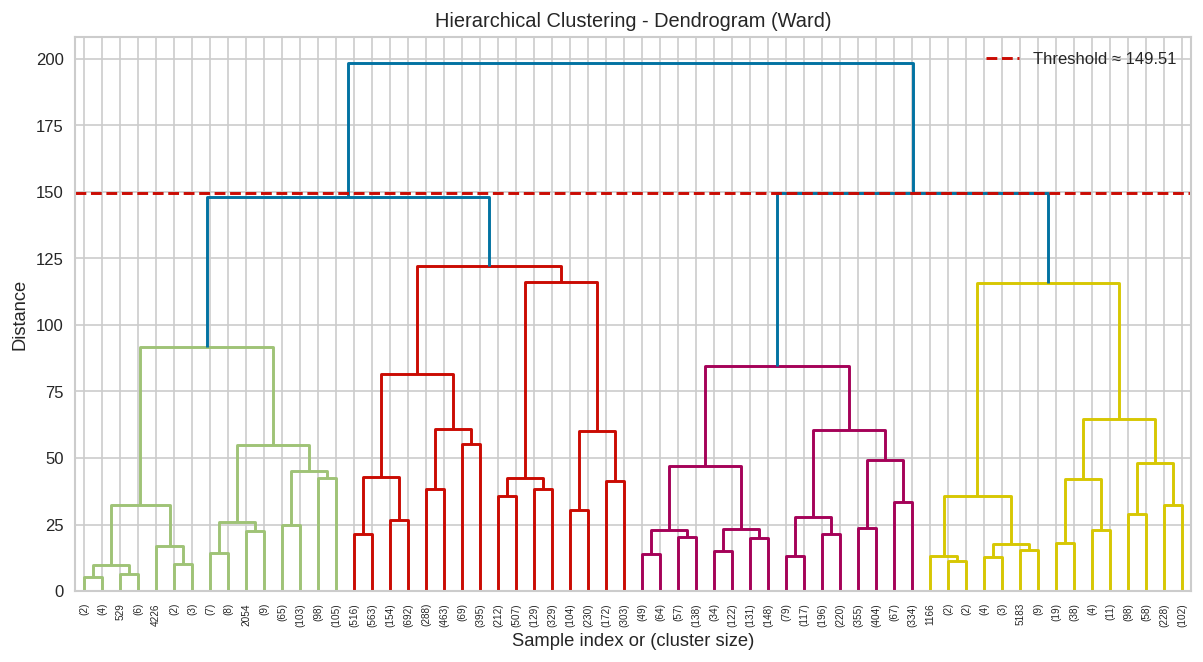

Clusters at threshold: 3


/home/dmitry/elbrus/Phase1/ds-phase1-git/week3/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/dmitry/elbrus/Phase1/ds-phase1-git/week3/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/dmitry/elbrus/Phase1/ds-phase1-git/week3/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and retu

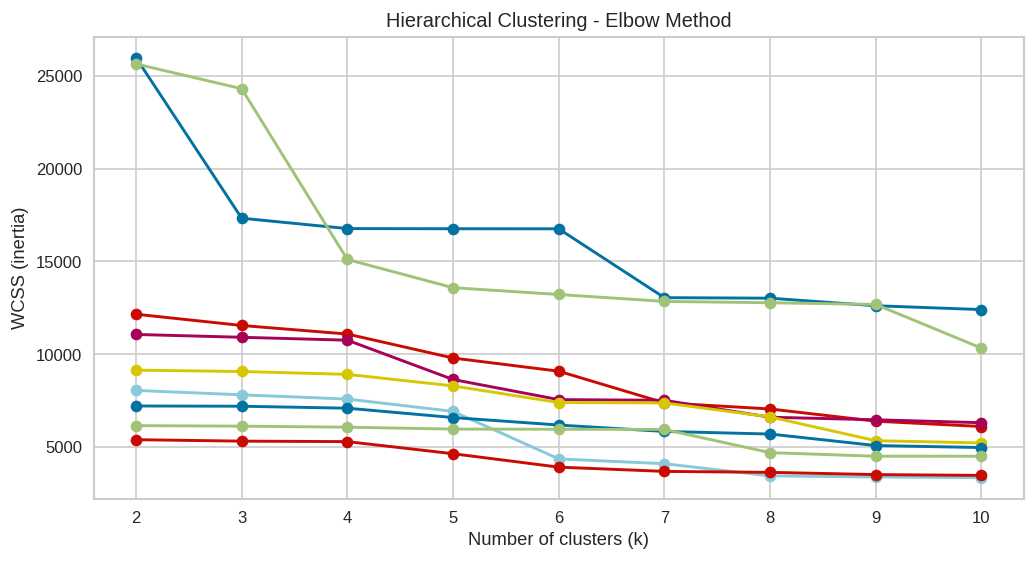

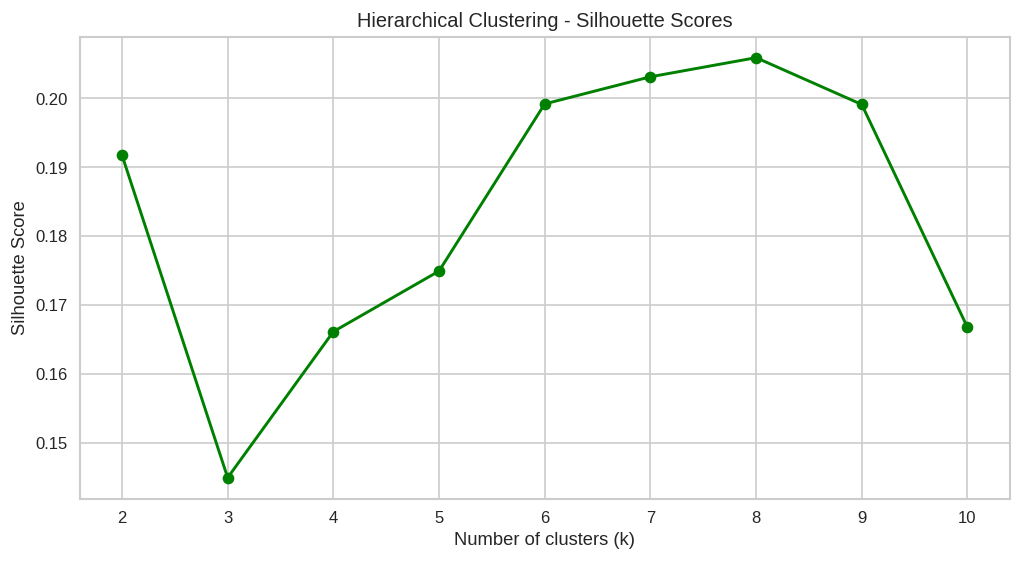

In [356]:
X = df_pca
Z = linkage(X, method="ward")

# Autopick a dendrogram cut threshold
h = np.sort(Z[:, 2])
tail_frac = 0.7
tail = h[int(tail_frac * len(h)) :]
tail_u = np.unique(tail)

if len(tail_u) >= 2:
    gaps = np.diff(tail_u)
    j = np.argmax(gaps)
    lower = tail_u[j]
    thr = np.nextafter(lower, -np.inf)
else:

    thr = np.nextafter(np.percentile(h, 90), -np.inf)

# Dendrogram with threshold line
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="level", p=5)
plt.axhline(y=thr, linestyle="--", color="r", label=f"Threshold ≈ {thr:.2f}")
plt.title("Hierarchical Clustering - Dendrogram (Ward)")
plt.xlabel("Sample index or (cluster size)")
plt.ylabel("Distance")
plt.legend()
plt.show()

labels_thr = fcluster(Z, t=thr, criterion="distance")
print("Clusters at threshold:", len(np.unique(labels_thr)))

# Elbow method for hierarchical clustering

K = range(2, 11)
inertia = []
sil_scores = []

for k in K:
    labels = fcluster(Z, k, criterion="maxclust")

    wcss = 0
    for cluster_id in np.unique(labels):
        cluster_points = X[labels == cluster_id]
        centroid = np.mean(cluster_points, axis=0)
        wcss += np.sum((cluster_points - centroid) ** 2)
    inertia.append(wcss)

    sil_scores.append(silhouette_score(X, labels))

# Elbow
plt.figure(figsize=(10, 5))
plt.plot(K, inertia, marker="o")
plt.title("Hierarchical Clustering - Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (inertia)")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(K, sil_scores, marker="o", color="green")
plt.title("Hierarchical Clustering - Silhouette Scores")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

In [358]:
Z

array([[4.21200000e+03, 6.14700000e+03, 3.49140731e-03, 2.00000000e+00],
       [2.95000000e+03, 5.42000000e+03, 6.35913298e-03, 2.00000000e+00],
       [5.29000000e+03, 5.76100000e+03, 9.89252759e-03, 2.00000000e+00],
       ...,
       [1.72640000e+04, 1.72670000e+04, 1.47951142e+02, 5.54100000e+03],
       [1.72630000e+04, 1.72650000e+04, 1.49508005e+02, 3.09500000e+03],
       [1.72680000e+04, 1.72690000e+04, 1.98394271e+02, 8.63600000e+03]],
      shape=(8635, 4))

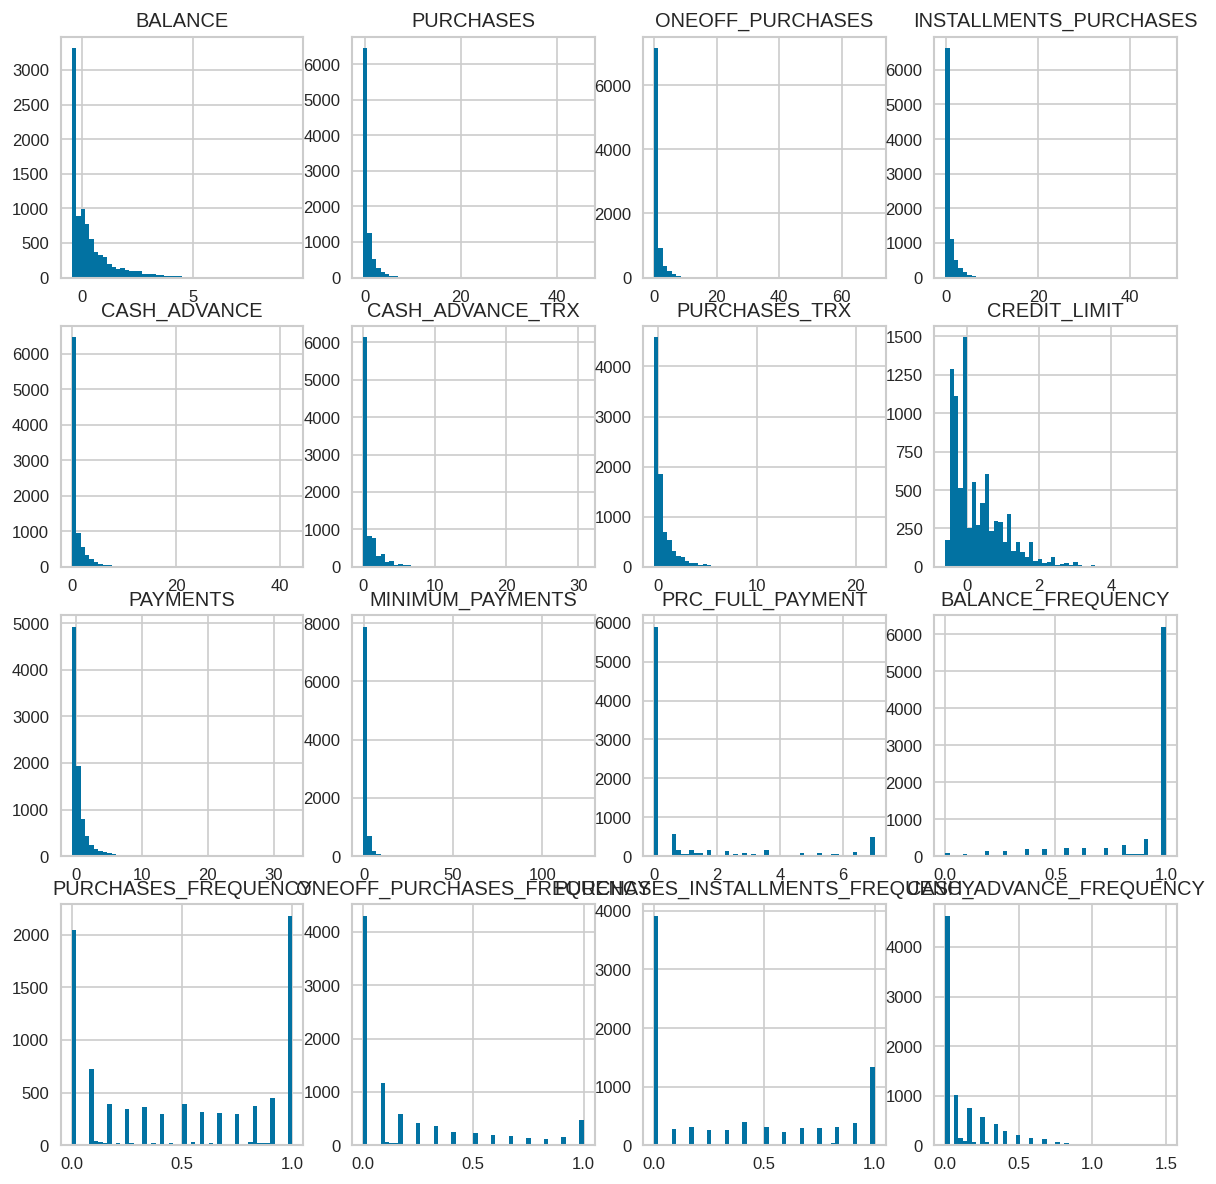

In [278]:
fig1, ax1 = plt.subplots(4, 4, figsize=(12, 12))
column_names = df_processed.columns.to_list()
k = 0
for i in np.arange(4):
    for j in np.arange(4):
        ax1[i, j].hist(df_processed[column_names[k]], bins=50)
        ax1[i, j].set_title(column_names[k])
        k += 1

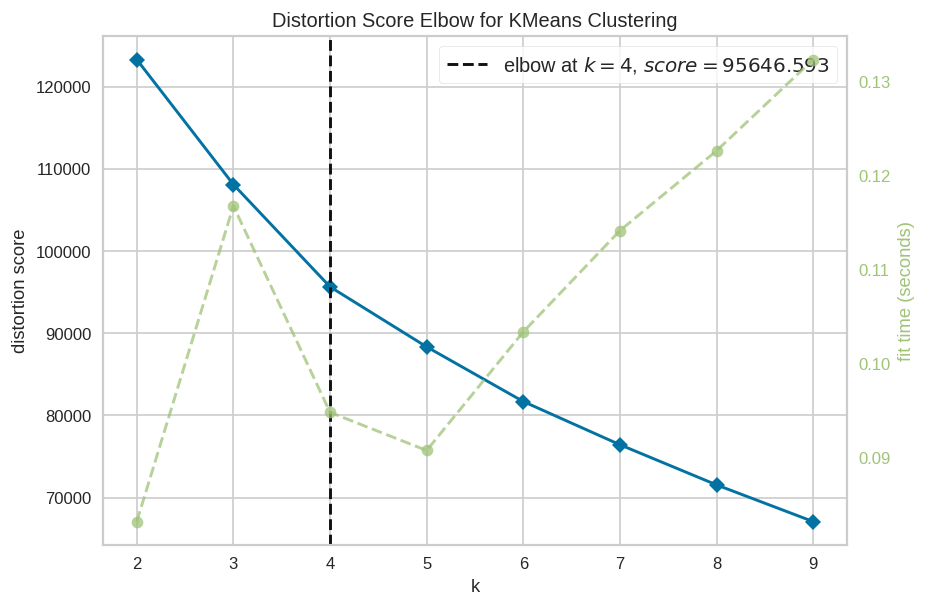

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [352]:
visualizer = KElbowVisualizer(
    KMeans(n_clusters=3, n_init=25, random_state=42, max_iter=500), k=(2, 10)
)
visualizer.fit(df_scaled)
visualizer.show()

In [353]:
km2 = KMeans(n_clusters=3, n_init=25, random_state=42, max_iter=500)

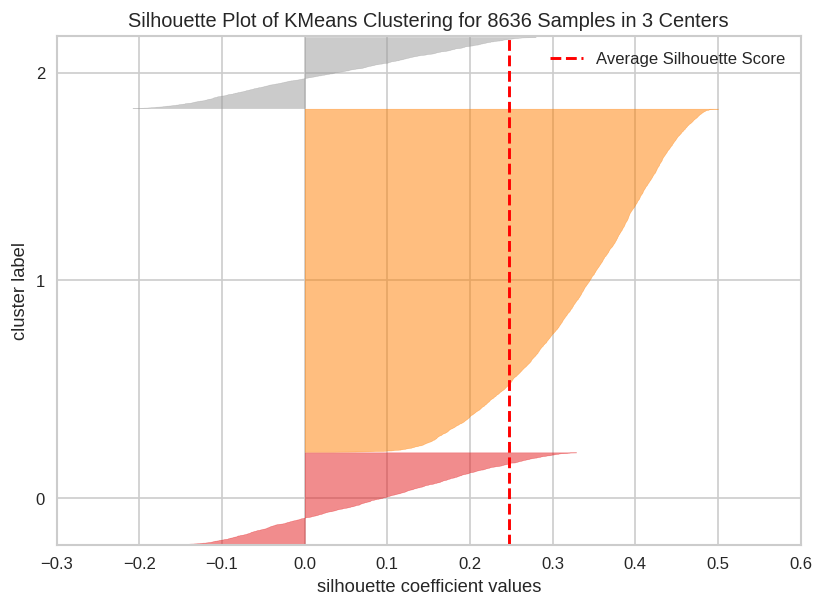

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 8636 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [354]:
visualizer_km2 = SilhouetteVisualizer(km2)
visualizer_km2.fit(df_scaled)
visualizer_km2.show()

In [286]:
pca2 = PCA(n_components=2)
tsne2 = TSNE(n_components=2, perplexity=30)
ump2 = UMAP(n_components=2, n_neighbors=50)

In [359]:
df_pca = pca2.fit_transform(df_scaled)
df_tsne = tsne2.fit_transform(df_scaled)
df_ump = ump2.fit_transform(df_scaled)

Text(0.5, 1.0, 'UMAP')

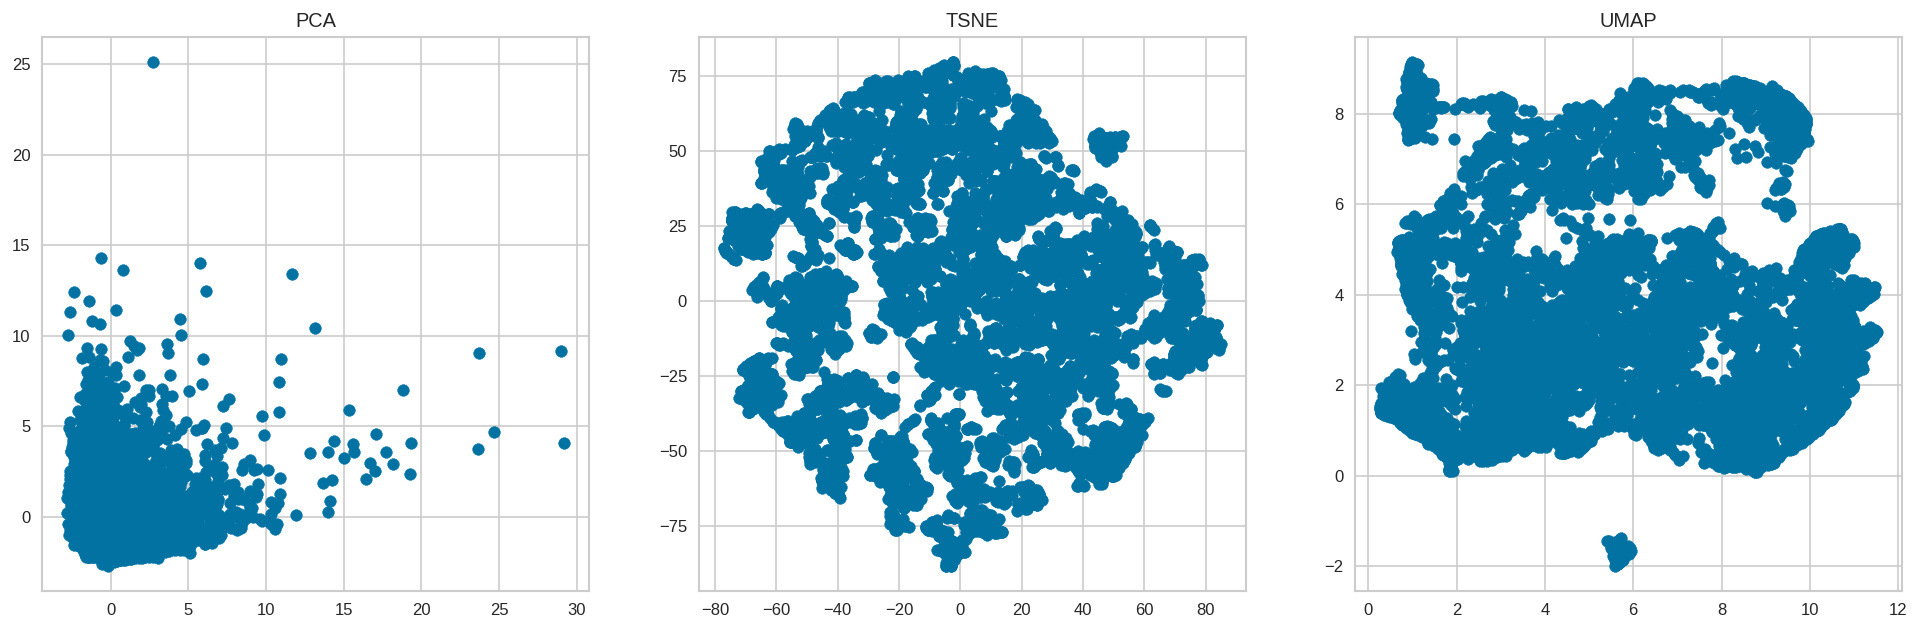

In [360]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.scatter(df_pca.iloc[:, 0], df_pca.iloc[:, 1])
ax2.scatter(df_tsne.iloc[:, 0], df_tsne.iloc[:, 1])
ax3.scatter(df_ump[:, 0], df_ump[:, 1])

ax1.set_title("PCA")
ax2.set_title("TSNE")
ax3.set_title("UMAP")

In [ ]:
# df_ump_3D = UMAP(n_components=3, n_neighbors=30)

In [361]:
reducers = {"pca": df_pca, "tsne": df_tsne, "umap": df_ump}

models2 = {
    "KMeans": KMeans(n_clusters=3, n_init=25, random_state=42, max_iter=500),
    "AggCls": AgglomerativeClustering(3),
    "DBSCAN": DBSCAN(eps=0.2),
}

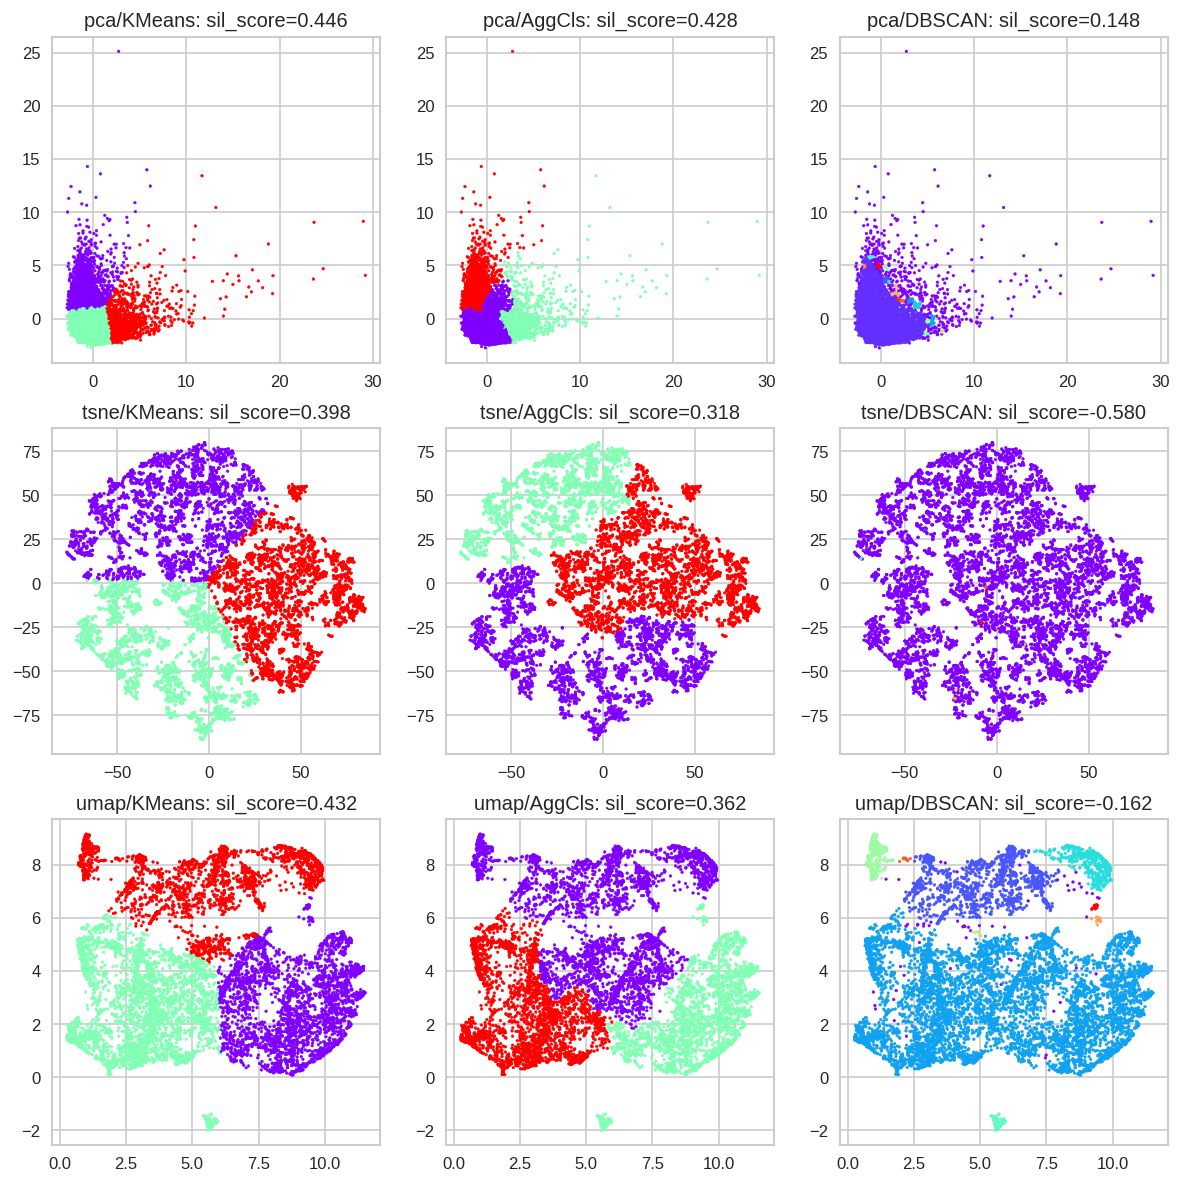

In [362]:
plot_results(reducers, models2)

In [363]:
final_model = KMeans(n_clusters=3, n_init=25, random_state=42, max_iter=500)

In [364]:
final_model.fit(df_pca)

,n_clusters,3
,init,'k-means++'
,n_init,25
,max_iter,500
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [366]:
cluster_labels = final_model.labels_

In [367]:
df_clusters = df.dropna()
df_clusters = df_clusters.drop(columns="CUST_ID")
df_clusters["Cluster"] = cluster_labels

In [372]:
summary = df_clusters.groupby("Cluster").mean()
summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,3865.517287,0.958206,349.968583,231.222089,118.820107,3703.690081,0.211007,0.103483,0.126215,0.431743,11.868452,4.970238,6502.750722,2939.511853,1758.411991,0.031762,11.375595
1,801.220823,0.859050,536.855983,273.679166,263.515785,303.524911,0.486843,0.145767,0.358082,0.066084,1.148161,9.244690,3287.654450,933.422764,512.072394,0.168176,11.503022
2,2312.651800,0.982812,4428.125940,2790.214300,1638.426661,519.989459,0.952493,0.652569,0.772049,0.068952,1.743348,58.318455,7802.017167,4349.289036,1325.831854,0.299121,11.919313


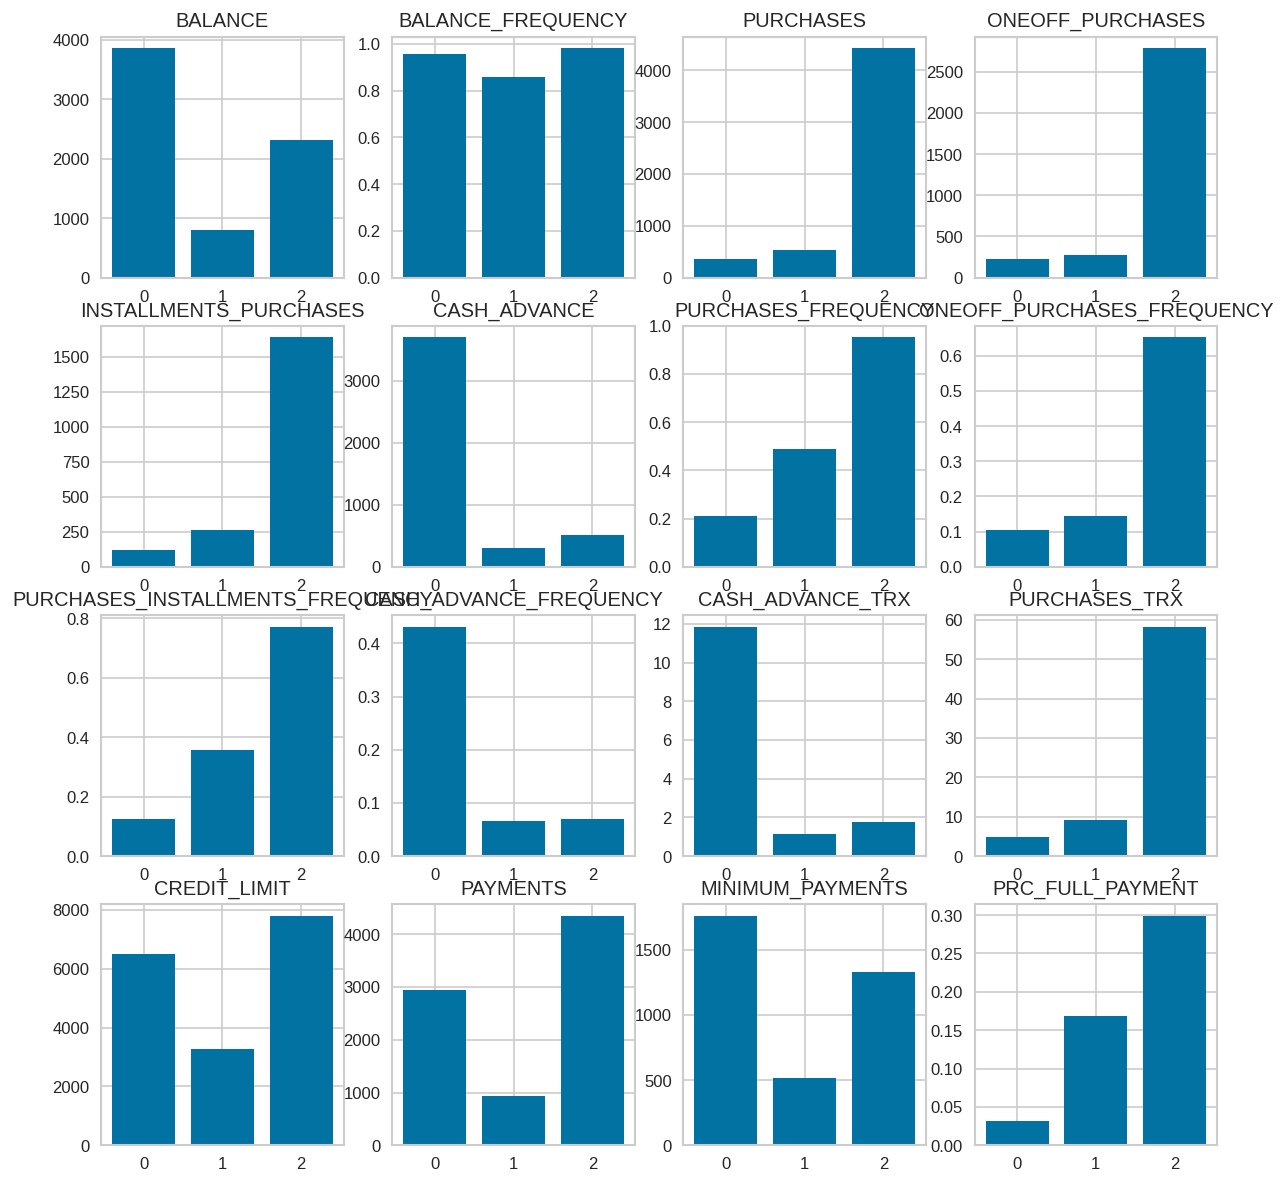

In [373]:
fig2, ax2 = plt.subplots(4, 4, figsize=(12, 12))
column_names = summary.columns.to_list()
k = 0
for i in np.arange(4):
    for j in np.arange(4):
        ax2[i, j].bar(summary.index, summary[column_names[k]])
        ax2[i, j].set_title(column_names[k])
        k += 1

<img src="https://icons.iconarchive.com/icons/icons8/windows-8/256/Programming-Github-icon.png" width=32 /> Сделай пуш на __github__. 